In [3]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [4]:
case_name = "MPHYS AT10"
#User choice:
solveConduction = True
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
#User choice:
solveConduction = True
zPlotting = []

If = 8
I1 = 3
# Sensitivity to the meshing parameters
Iz1 = 70 # number of control volumes in the axial direction, added 70 for comparison with GeN-Foam
# Iz1 = 10, 20, 40, 50, 70, 80 and 160 are supported for the DONJON solution


########## Choice of Thermalhydraulics correlation ##########
voidFractionCorrel = 'EPRIvoidCorrel' # 'modBestion', 'HEM1', 'GEramp', 'EPRIvoidModel'
frfaccorel = "Churchill" # 'base', 'blasius', 'Churchill', 'Churchill_notOK' ?
P2Pcorel = "lockhartMartinelli" # 'base', 'HEM1', 'HEM2', 'MNmodel', "lockhartMartinelli"
numericalMethod = "FVM" # "FVM": Solves the system using matrix inversion with preconditioning.
                        # "GaussSiedel" : Applies the Gauss-Seidel iterative solver.
                        # "BiCG" : Uses the BiConjugate Gradient method for solving non-symmetric or indefinite matrices.
                        # "BiCGStab" : Applies the BiCGStab (BiConjugate Gradient Stabilized) method to ensure faster and more stable convergence.

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square" # "square", "cylindrical"
pitch =1.295e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
fuelRadius = 0.4435e-2 # m : fuel rod radius
gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius = 0.5140e-2 # m : clad external radius
height = 1.155 #2.155# m : height : 3.8 m : active core height in BWRX-300 SMR, 1.555 m : for GeNFoam comparison.


## Fluid parameters

# T_inlet, T_outlet = 270, 287 Celcius
tInlet = 270 + 273.15 # K, for BWRX-300 SMR core, try lowering the inlet temperature to set boiling point back and reduce the void fraction increase in the first few cm
#tInlet = 560# # K, for BWRX-300 SMR core
#Nominal operating pressure = 7.2 MPa (abs)
pOutlet =  7.2e6 # Pa
# Nominal coolant flow rate = 1530 kg/s
massFlowRate = 8.407 * 10**(-2) #1530  / (200*91)  # kg/s

## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000 
#Hgap = 9000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity


############ Nuclear Parameters ###########
# Number of fuel rods and assemblies for a small modular Boiling Water Reactor core
caseNumber = 0.5#0.5 #
qFiss = 1.0e8 * caseNumber # W/m3 : Volumetric fission power density
qFiss_init = []
for i in range(Iz1):
    qFiss_init.append(qFiss)

case0 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, pitch, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, qFiss_init, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = 'EPRIvoidModel',
                            numericalMethod = numericalMethod)

print(f'Uinlet: {case0.convection_sol.U[-1][0]} m/s')

$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.155 m with 70 axial elements.
self.I_z: 70
self.qFlow: 0.08407
self.pOutlet: 7200000.0
self.Lf: 1.155
self.r_f: 0.004435
self.clad_r: 0.00514
self.r_w: 0.01295
self.Dz: 0.0165
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Velocity at the inlet:  1.2886310733566793
cote: 0.01295
cladRadius: 0.00514
Dh: 0.010490958633360763
Hydraulic diameter: [0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.010490958633360763, 0.01049

c:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\THM_waterProp.py:567: RuntimeWarning: divide by zero encountered in scalar divide
  return self.U[i] - (self.voidFractionTEMP[i] / ( 1 - self.voidFractionTEMP[i])) * (self.rhogTEMP[i] / self.rhoTEMP[i]) * self.VgjPrimeTEMP[i]
c:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\THM_waterProp.py:580: RuntimeWarning: invalid value encountered in sqrt
  return 1 + 1/np.sqrt(X) + 20/X


Convergence test, residuals: epsilon: 0.4778672858201771, rho: 0.45299900967905316, xTh: 8.366600265340756
uInlet:1.2891313454893862
VAR_VFM_Class: [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-6.23467003e-02  6.23467252e-02  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -6.23467252e-02  6.23467501e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -8.47028787e-05
   8.47028787e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
  -8.47028787e-05  8.47028787e-05]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  1.00000000e+00]]
VAR_VFM_Class: [ 1.28913135e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00

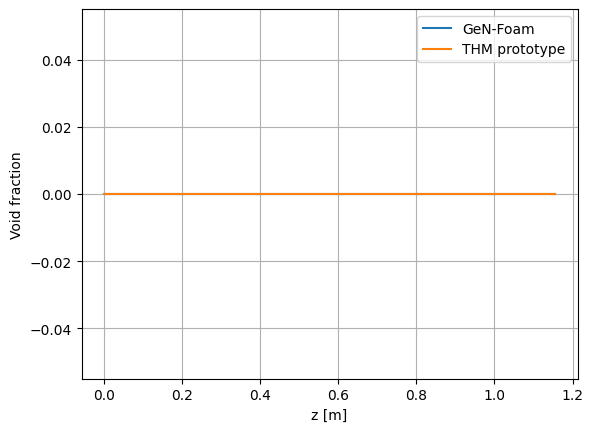

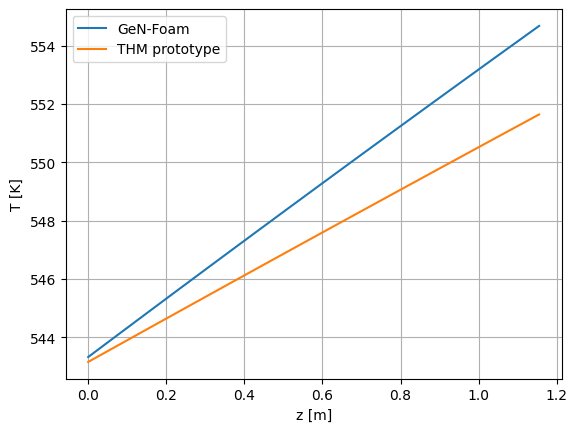

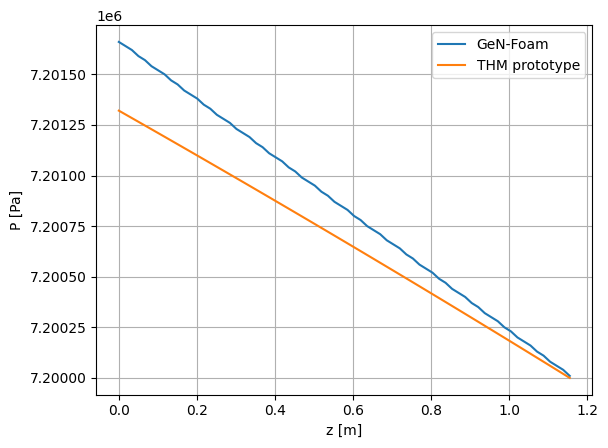

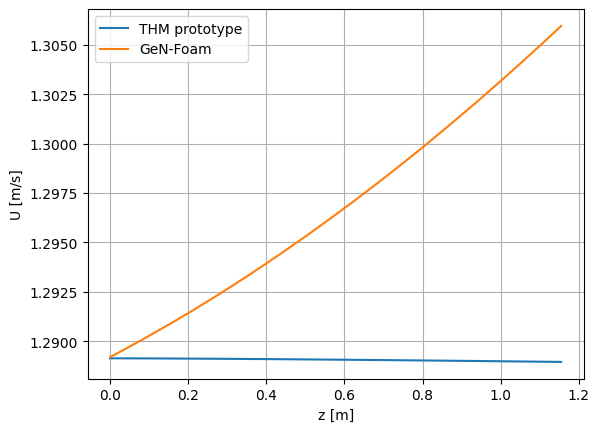

In [5]:
voidGF = [0]*70

voidGF = [voidGF[i]/(1-0.494922) for i in range(Iz1)]
TGF = [
    543.318, 543.486, 543.654, 543.822, 543.99, 544.158, 544.325, 544.493, 544.66, 544.828,
    544.995, 545.162, 545.329, 545.496, 545.663, 545.829, 545.996, 546.162, 546.329, 546.495,
    546.661, 546.827, 546.993, 547.159, 547.324, 547.49, 547.656, 547.821, 547.986, 548.152,
    548.317, 548.482, 548.646, 548.811, 548.976, 549.141, 549.305, 549.469, 549.634, 549.798,
    549.962, 550.126, 550.29, 550.453, 550.617, 550.78, 550.944, 551.107, 551.27, 551.433,
    551.596, 551.759, 551.922, 552.085, 552.247, 552.41, 552.572, 552.734, 552.896, 553.058,
    553.22, 553.382, 553.544, 553.705, 553.867, 554.028, 554.189, 554.351, 554.512, 554.673
]
PGF = [
    7.20166e+06, 7.20164e+06, 7.20162e+06, 7.20159e+06, 7.20157e+06, 7.20154e+06, 7.20152e+06, 7.2015e+06,
    7.20147e+06, 7.20145e+06, 7.20142e+06, 7.2014e+06, 7.20138e+06, 7.20135e+06, 7.20133e+06, 7.2013e+06,
    7.20128e+06, 7.20126e+06, 7.20123e+06, 7.20121e+06, 7.20119e+06, 7.20116e+06, 7.20114e+06, 7.20111e+06,
    7.20109e+06, 7.20107e+06, 7.20104e+06, 7.20102e+06, 7.20099e+06, 7.20097e+06, 7.20095e+06, 7.20092e+06,
    7.2009e+06, 7.20087e+06, 7.20085e+06, 7.20083e+06, 7.2008e+06, 7.20078e+06, 7.20075e+06, 7.20073e+06,
    7.20071e+06, 7.20068e+06, 7.20066e+06, 7.20064e+06, 7.20061e+06, 7.20059e+06, 7.20056e+06, 7.20054e+06,
    7.20052e+06, 7.20049e+06, 7.20047e+06, 7.20044e+06, 7.20042e+06, 7.2004e+06, 7.20037e+06, 7.20035e+06,
    7.20032e+06, 7.2003e+06, 7.20028e+06, 7.20025e+06, 7.20023e+06, 7.2002e+06, 7.20018e+06, 7.20016e+06,
    7.20013e+06, 7.20011e+06, 7.20008e+06, 7.20006e+06, 7.20004e+06, 7.20001e+06
]

UGF = [
    1.2892, 1.28937, 1.28955, 1.28973, 1.28991, 1.29009, 1.29028, 1.29047, 1.29066, 1.29085,
    1.29104, 1.29124, 1.29143, 1.29163, 1.29184, 1.29204, 1.29224, 1.29245, 1.29266, 1.29287,
    1.29309, 1.2933, 1.29352, 1.29374, 1.29396, 1.29419, 1.29441, 1.29464, 1.29487, 1.2951,
    1.29533, 1.29557, 1.29581, 1.29605, 1.29629, 1.29653, 1.29678, 1.29702, 1.29727, 1.29752,
    1.29778, 1.29803, 1.29829, 1.29855, 1.29881, 1.29907, 1.29934, 1.2996, 1.29987, 1.30014,
    1.30042, 1.30069, 1.30097, 1.30125, 1.30153, 1.30181, 1.30209, 1.30238, 1.30267, 1.30296,
    1.30325, 1.30355, 1.30384, 1.30414, 1.30444, 1.30474, 1.30504, 1.30535, 1.30566, 1.30597
]


z = case0.convection_sol.z_mesh
fig1, ax1 = plt.subplots()
ax1.plot(z, voidGF, label = "GeN-Foam")
ax1.plot(z, case0.convection_sol.voidFraction[-1], label = "THM prototype")
ax1.set_xlabel("z [m]")
ax1.set_ylabel("Void fraction")
ax1.grid()
ax1.legend()

fig2, ax2 = plt.subplots()
ax2.plot(z, TGF, label = "GeN-Foam")
ax2.plot(z, case0.convection_sol.T_water, label = "THM prototype")
ax2.set_xlabel("z [m]")
ax2.set_ylabel("T [K]")
ax2.grid()
ax2.legend()

fig3, ax3 = plt.subplots()
ax3.plot(z, PGF, label = "GeN-Foam")
ax3.plot(z, case0.convection_sol.P[-1], label = "THM prototype")
ax3.set_xlabel("z [m]")
ax3.set_ylabel("P [Pa]")
ax3.grid()
ax3.legend()

fig4, ax4 = plt.subplots()
ax4.plot(z, case0.convection_sol.U[-1], label = "THM prototype")
ax4.plot(z, UGF, label = "GeN-Foam")
ax4.set_xlabel("z [m]")
ax4.set_ylabel("U [m/s]")
ax4.grid()
ax4.legend()

plt.show()

